# RAG Bench — 72-Combo Benchmark on Google Colab

한국어 RAG 파이프라인 72개 조합을 Google Colab T4 GPU에서 벤치마크합니다.

## 3-Layer Architecture
```
Layer 1: Dense Model ─── kosimcse | e5 | bge-m3 | minilm       (4종)
Layer 2: Sparse Model ── korean_bm25 | splade | fastembed_bm25 (3종)
Layer 3: Retrieval Mode ─ hybrid × reranker × llm_support      (6종)
                          ├── hybrid (기본)
                          ├── hybrid + contextual
                          ├── hybrid + colbert_rerank
                          ├── hybrid + colbert_rerank + contextual
                          ├── hybrid + flashrank_rerank
                          └── hybrid + flashrank_rerank + contextual

총 조합: 4 × 3 × 6 = 72개 + GraphRAG
```

## 2-Pass Execution
- **Pass 1**: 전체 조합 레이턴시 측정 (API 비용 $0)
- **Pass 2**: 상위 N개만 RAGAS 평가 (API 비용 절감)
  - **메트릭 프리셋**: `core_only` (4) | `comprehensive` (7) | `full` (11+) | `reference_free`
  - **스코어링 프로파일**: `balanced` | `precision_critical` | `speed_critical` | `comprehensive`

## 예상 실행시간 (T4 GPU)
| 프리셋 | 조합 수 | Pass 1 | Pass 2 | 총 예상 |
|--------|---------|--------|--------|--------|
| quick | 4 | ~3분 | ~10분 | ~15분 |
| standard | 24 | ~20분 | ~30분 | ~50분 |
| full | 72 | ~1시간 | ~2시간 | ~3시간 |
| +GraphRAG | +1 | +5분 | +10분 | +15분 |

---
## Section 1: 환경 설정

In [ ]:
# Cell 1.1: Repo clone + sys.path 설정
import os
import sys

REPO_URL = "https://github.com/SukbeomH/RAG-Bench.git"  # <- 본인 repo URL로 변경
REPO_DIR = "/content/RAG-Bench"

if not os.path.exists(REPO_DIR):
    !git clone {REPO_URL} {REPO_DIR}
else:
    print(f"Repo already cloned: {REPO_DIR}")
    !git -C {REPO_DIR} pull

# sys.path에 추가 (패키지 import용)
for p in [REPO_DIR, os.path.join(REPO_DIR, "rag_bench_colab")]:
    if p not in sys.path:
        sys.path.insert(0, p)

print(f"sys.path 설정 완료")
print(f"Python: {sys.version}")

In [7]:
# Cell 1.2: 시스템 의존성 + 패키지 설치
import os
import subprocess

!apt-get install -y default-jdk -qq

# Colab 사전 설치 torch 버전 보존 (CUDA 호환성)
# sentence-transformers, pylate 등이 PyPI의 torch를 끌어오는 것을 방지
_torch_ver = subprocess.check_output(
    ['python', '-c', 'import torch; print(torch.__version__)']
).decode().strip()
print(f"[torch] Colab 사전 설치 버전: {_torch_ver} (보존)")

os.system(
    f'pip install -q '
    f'-r /content/RAG-Bench/rag_bench_colab/requirements_colab.txt '
    f'"torch=={_torch_ver}"'
)
print("[완료] 패키지 설치 완료")

[torch] Colab 사전 설치 버전: 2.9.0+cu128 (보존)
[완료] 패키지 설치 완료


In [8]:
# Cell 1.3: Colab 환경 초기화 + rag_bench 패치 + smoke test
from colab_config import init_colab

env_info = init_colab(
    qdrant_mode="ephemeral",  # 'ephemeral' | 'drive' | 'memory'
    device=None,               # None = 자동 감지 (T4 → 'cuda')
    mount_drive=True,
)

# Smoke test: 핵심 모듈 import
from rag_bench.config import BENCH_DATA_DIR, BENCH_DOCS_DIR
from rag_bench.scripts.run_all_combos import PRESETS, generate_valid_combinations, ComboSpec
from rag_bench.runner import BenchmarkRunner
print("\n[Smoke Test] 모든 import 성공!")
print(f"  BENCH_DATA_DIR: {BENCH_DATA_DIR}")
print(f"  BENCH_DOCS_DIR: {BENCH_DOCS_DIR}")

[Device] CUDA: NVIDIA A100-SXM4-40GB
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[Warning] Colab Secrets 접근 실패. 수동으로 API Key를 설정하세요.

[Setup] 환경 설정 완료:
  is_colab: True
  device: cuda
  drive_mounted: True
  api_key_loaded: False
  hf_home: /content/drive/MyDrive/rag_bench_colab/models
[Patch] rag_bench.config 패치 완료:
  BENCH_DOCS_DIR → /content/RAG-Bench/rag_bench_colab/data/docs
  BENCH_DATA_DIR → /content/drive/MyDrive/rag_bench_colab/_benchdata
  MODELS_DIR     → /content/drive/MyDrive/rag_bench_colab/models
  Qdrant mode    → ephemeral
[Patch] huggingface_hub.list_repo_tree → additional_chat_templates 404 억제
[Patch] DenseSparseStrategy._init_dense → device='cuda', trust_remote_code=True

 Colab 환경 초기화 완료

[Smoke Test] 모든 import 성공!
  BENCH_DATA_DIR: /content/drive/MyDrive/rag_bench_colab/_benchdata
  BENCH_DOCS_DIR: /content/RAG-Bench/rag_bench_colab/data/docs


In [ ]:
# Cell 1.4: API Key 설정 (자동 로드 실패 시 수동 입력)
import os

if not env_info.get("api_key_loaded", False):
    import getpass
    _key = getpass.getpass("OPENAI_API_KEY 입력 (Enter로 건너뜀): ")
    if _key.strip():
        os.environ["OPENAI_API_KEY"] = _key.strip()
        print("[API Key] 수동 입력 완료")
    else:
        print("[Warning] OPENAI_API_KEY 미설정 — Pass 2 RAGAS 평가가 실패할 수 있습니다.")
else:
    print("[API Key] 이미 로드됨")

---
## Section 2: 설정

### QDRANT_MODE 선택 가이드

| 모드 | 저장 위치 | 세션 종료 후 | 추천 상황 |
|------|-----------|-------------|-----------|
| `ephemeral` | `/content/qdrant_workspace` (로컬) | **삭제됨** | 빠른 테스트, 재현 불필요 |
| `drive` | `Google Drive/MyDrive/rag_bench_colab/` | **유지됨** | 장시간 실험, 결과 보존 필요 |
| `memory` | 메모리 (RAM) | **삭제됨** | 가장 빠름, 소규모 실험 |

> **권장**: 처음 실행은 `ephemeral`, 결과를 보존하려면 `drive`
>
> `drive` 모드는 Cell 1.3의 `mount_drive=True` 필요 (Google Drive 마운트)

### INCLUDE_GRAPHRAG 옵션

| 값 | 동작 |
|----|------|
| `False` | 기본값. 3-Layer 조합(최대 72개)만 실행 |
| `True` | GraphRAG(LightRAG)를 조합에 추가. 동일한 Pass 1/2 파이프라인으로 비교 가능 |

> **비용 주의**: `True` 설정 시 LLM이 문서에서 지식 그래프를 구축하므로  
> 인덱싱 단계에서 추가 API 비용과 시간이 발생합니다.

### 기타 파라미터

| 파라미터 | 설명 |
|----------|------|
| `PRESET` | 벤치마크 조합 수 — `quick` (4) / `standard` (24) / `full` (72) |
| `K` | 검색 시 반환할 문서 수 |
| `TOP_N` | Pass 1 완료 후 RAGAS 평가할 상위 전략 수 |
| `METRIC_PRESET` | 평가 메트릭 세트 — `core_only` / `comprehensive` / `full` / `reference_free` |
| `SCORING_PROFILE` | 가중 점수 프로파일 — `balanced` / `precision_critical` / `speed_critical` / `comprehensive` |

In [9]:
# ===== 사용자 설정 =====
PRESET = "quick"     # 'quick' (4조합) | 'standard' (24) | 'full' (72)
K = 3                # 검색 결과 수
TOP_N = 4            # Pass 2 RAGAS 평가 대상 (상위 N)

# QDRANT_MODE:
#   'ephemeral' → /content/qdrant_workspace  (세션 종료 시 삭제, 기본값)
#   'drive'     → Google Drive/rag_bench_colab/ (영구 보존, mount_drive=True 필요)
#   'memory'    → RAM 전용 (가장 빠름, 세션 종료 시 삭제)
QDRANT_MODE = "ephemeral"

# INCLUDE_GRAPHRAG:
#   True  → GraphRAG(LightRAG)를 조합에 포함. 프리셋 전략과 동일한 Pass 1/2로 비교.
#            LLM으로 지식 그래프를 구축하므로 인덱싱 비용($) 및 시간 추가 발생.
#   False → 기존 3-Layer 조합만 실행 (기본값)
INCLUDE_GRAPHRAG = False

# 평가 설정 (rag_bench evaluation 최신화 반영)
METRIC_PRESET = "core_only"    # 'core_only' (4) | 'comprehensive' (7) | 'full' (11+) | 'reference_free'
SCORING_PROFILE = "balanced"   # 'balanced' | 'precision_critical' | 'speed_critical' | 'comprehensive'
# ======================

print(f"Preset: {PRESET}")
print(f"K: {K}, Top-N: {TOP_N}")
print(f"Qdrant Mode: {QDRANT_MODE}")
print(f"GraphRAG: {'ON (조합 포함)' if INCLUDE_GRAPHRAG else 'OFF'}")
print(f"Metric Preset: {METRIC_PRESET}")
print(f"Scoring Profile: {SCORING_PROFILE}")

Preset: quick
K: 3, Top-N: 4
Qdrant Mode: ephemeral
GraphRAG: OFF
Metric Preset: core_only
Scoring Profile: balanced


---
## Section 3: 데이터 로딩

In [10]:
# Cell 3.1: 러너 생성 + 데이터 로드
from colab_runner import ColabBenchmarkRunner

runner = ColabBenchmarkRunner(
    preset=PRESET,
    k=K,
    top_n=TOP_N,
    qdrant_mode=QDRANT_MODE,
    metric_preset=METRIC_PRESET,
    scoring_profile=SCORING_PROFILE,
    include_graphrag=INCLUDE_GRAPHRAG,
)

child_chunks, parent_pairs, queries, ground_truths = runner.prepare_data()

print(f"\nQA 샘플:")
for i, q in enumerate(queries[:3]):
    print(f"  Q{i+1}: {q[:80]}...")
    print(f"  A{i+1}: {ground_truths[i][:80]}...")

TypeError: ColabBenchmarkRunner.__init__() got an unexpected keyword argument 'include_graphrag'

In [ ]:
# Cell 3.2: Parent-Child 청킹 통계
print(f"Parent 청크: {len(parent_pairs)}개")
print(f"Child 청크: {len(child_chunks)}개")
print(f"\n샘플 Child 청크 (첫 번째):")
print(child_chunks[0].page_content[:300])

Parent 청크: 33개
Child 청크: 763개

샘플 Child 청크 (첫 번째):
**Knowledge Cutoff |** 2025. 9. 10


---
## Section 4: 조합 생성

In [ ]:
# 프리셋 기반 ComboSpec 생성
combos = runner.generate_combos()

import pandas as pd
combo_table = pd.DataFrame([
    {
        "#": i+1,
        "Label": spec.label,
        "Dense": spec.dense,
        "Sparse": spec.sparse,
        "Reranker": spec.reranker or "-",
        "LLM Support": spec.llm_support or "-",
    }
    for i, spec in enumerate(combos)
])
display(combo_table)

[Combos] 프리셋 'quick': 4개 조합 생성


,#,Label,Dense,Sparse,Reranker,LLM Support
0,1,bge-m3+fastembed_bm25,bge-m3,fastembed_bm25,-,-
1,2,bge-m3+fastembed_bm25+flashrank,bge-m3,fastembed_bm25,flashrank,-
2,3,minilm+fastembed_bm25,minilm,fastembed_bm25,-,-
3,4,minilm+fastembed_bm25+flashrank,minilm,fastembed_bm25,flashrank,-


---
## Section 5: Pass 1 — 레이턴시 벤치마크

In [ ]:
# Pass 1: 전체 조합 레이턴시 측정
latency_df = runner.run_pass1(combos, queries, child_chunks, parent_pairs)
display(latency_df)


[Pass 1] 레이턴시 벤치마크 시작
  조합: 4개, 쿼리: 20개
  이미 완료: 0개


Pass 1: 전략 빌드 & 검색:   0%|          | 0/4 [00:00<?, ?it/s]


[DS(bge-m3+fastembed_bm25)] 초기화 중...


model.safetensors:   0%|          | 0.00/2.27G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/444 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

  Dense: sentence-transformers/all-MiniLM-L6-v2 (384d, device=cuda)
  Sparse: fastembed_bm25
  Created collection: document_child_chunks (dim=384)
  Created collection: document_child_chunks (dim=384)
  Indexing 763 documents...
  Indexing complete.

전략: DS(all-MiniLM-L6-v2+fastembed_bm25)
설명: Hybrid: all-MiniLM-L6-v2 (dense) + fastembed_bm25 (sparse)
  [   22.3ms] 주어진 데이터에서 가장 큰 숫자는 무엇인가요?... → 3 results
  [   19.8ms] 엔비디아의 NVLink Fusion 전략은 무엇을 목표로 하고 있나요?... → 3 results
  [   20.4ms] AI DC가 전력망에 대한 의존도를 낮추기 위해 지향하는 방식은 무엇인가요?... → 3 results
  [   19.6ms] OpenAI의 GPT-6가 목표로 하는 세 가지 핵심 축은 무엇인가요?... → 3 results
  [   19.2ms] IgniteTech의 CEO 에릭 보건은 기존 인력을 어떻게 변화시키기로 결정했나요?... → 3 results
  [   18.8ms] 메타가 AI 엔지니어를 영입하기 위해 어떤 방식으로 접근했는가?... → 3 results
  [   19.4ms] 중국 AI 시장에서 DeepSeek의 주요 성과는 무엇인가요?... → 3 results
  [   18.9ms] 일론 머스크가 작성한 X 게시물의 주요 테마는 무엇인가요?... → 3 results
  [   18.3ms] 팔란티어는 저렴해진 AI 모델을 어떻게 활용하고 있나요?... → 3 results
  [   20.0ms] AI 발전의 속도가 인간의 연구 역량에 비해 얼마나 빠르게 증가하고 

,strategy,avg_latency_ms,std_latency_ms,query_count,avg_latency
0,DS(all-MiniLM-L6-v2+fastembed_bm25),19.415,1.027657,20,0.019415
1,DS(bge-m3+fastembed_bm25),55.355,2.213470,20,0.055355
2,FlashRank Rerank (DS(all-MiniLM-L6-v2+fastembe...,2188.180,132.103869,20,2.188180
3,FlashRank Rerank (DS(bge-m3+fastembed_bm25)),2347.575,276.301976,20,2.347575


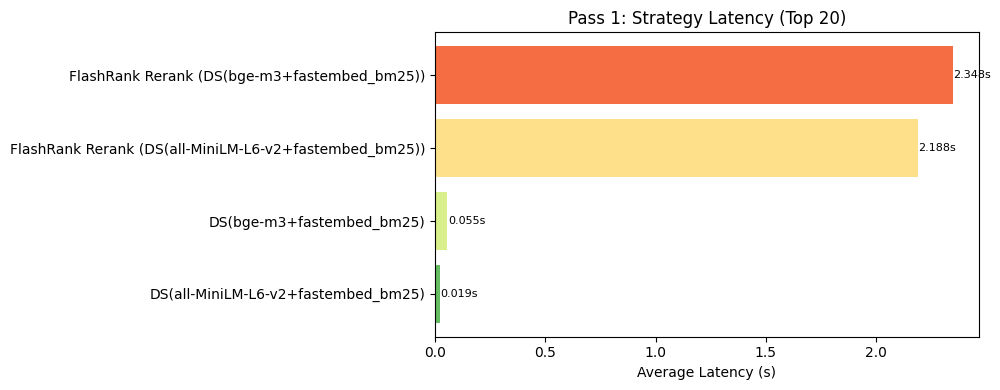

In [ ]:
# Pass 1 시각화
from colab_visualizer import plot_latency_comparison
plot_latency_comparison(latency_df)

---
## Section 6: Pass 2 — RAGAS 평가

In [ ]:
# Pass 2: 상위 N개 전략 RAGAS 평가 (체크포인트 지원)
ragas_df = runner.run_pass2(
    latency_df, combos, queries, ground_truths,
    child_chunks, parent_pairs,
)
display(ragas_df)


[Pass 2] RAGAS 평가 시작
  메트릭 프리셋: core_only
  스코어링 프로파일: balanced
  상위 4개 전략:
    1. DS(all-MiniLM-L6-v2+fastembed_bm25) (0.019s)
    2. DS(bge-m3+fastembed_bm25) (0.055s)
    3. FlashRank Rerank (DS(all-MiniLM-L6-v2+fastembed_bm25)) (2.188s)
    4. FlashRank Rerank (DS(bge-m3+fastembed_bm25)) (2.348s)


Pass 2: RAGAS 평가:   0%|          | 0/4 [00:00<?, ?it/s]

  [Skip] DS(all-MiniLM-L6-v2+fastembed_bm25): ComboSpec 매칭 실패
  결과 주입 완료: 1개 전략 (재검색 생략)
  [Warning] 답변 생성 실패: The api_key client option must be set either by passing api_key to the client or by setting the OPENAI_API_KEY environment variable
  [DS(bge-m3+fastembed_bm25)] {}
    weighted(balanced): 0.0000
[Memory] CUDA cache cleared. Allocated: 2262MB
  [Skip] FlashRank Rerank (DS(all-MiniLM-L6-v2+fastembed_bm25)): ComboSpec 매칭 실패
  [Skip] FlashRank Rerank (DS(bge-m3+fastembed_bm25)): ComboSpec 매칭 실패

[Pass 2] 완료: 1개 전략 평가


,strategy,weighted_balanced
0,DS(bge-m3+fastembed_bm25),0.0


In [ ]:
# RAGAS 결과 스타일링 테이블
from colab_visualizer import display_styled_table, display_weighted_scores
display_styled_table(ragas_df)

# Weighted Score (프로파일별 가중 점수)
if runner.reports:
    print(f"\n--- Weighted Scores (profile={SCORING_PROFILE}) ---")
    display_weighted_scores(runner.reports, scoring_profile=SCORING_PROFILE)

,strategy,weighted_balanced
0,DS(bge-m3+fastembed_bm25),0.0000



--- Weighted Scores (profile=balanced) ---


,strategy,balanced,precision_critical,speed_critical,comprehensive
rank,,,,,
1,DS(bge-m3+fastembed_bm25),0.0000,0.0000,0.0000,0.0000


---
## Section 7: GraphRAG

GraphRAG는 Section 2의 `INCLUDE_GRAPHRAG` 옵션으로 제어됩니다.

- `INCLUDE_GRAPHRAG = True` → Section 4 조합 목록에 `graphrag` 항목이 추가되어  
  Pass 1(레이턴시) / Pass 2(RAGAS) 파이프라인을 기존 전략과 **동일한 기준**으로 비교
- `INCLUDE_GRAPHRAG = False` → GraphRAG 제외 (기본값)

> **비용 주의**: GraphRAG는 인덱싱 시 LLM으로 지식 그래프를 구축합니다.  
> 문서 수에 따라 추가 API 비용($)과 시간이 발생합니다.

In [ ]:
# GraphRAG 결과는 INCLUDE_GRAPHRAG=True 설정 시 ragas_df에 자동 포함됩니다.
if runner.include_graphrag:
    graphrag_rows = ragas_df[ragas_df["strategy"] == "graphrag"] if ragas_df is not None else None
    if graphrag_rows is not None and not graphrag_rows.empty:
        print("[GraphRAG] RAGAS 결과:")
        display(graphrag_rows)
    else:
        print("[GraphRAG] 결과 없음 (Pass 2 미실행 또는 오류)")
else:
    print("[GraphRAG] 비활성화됨 (INCLUDE_GRAPHRAG=False)")

In [ ]:
# GraphRAG는 이제 ragas_df에 통합되어 별도 병합이 불필요합니다.
# (이 셀은 이전 버전 호환성을 위해 유지)
pass

---
## Section 8: 시각화 대시보드

수행 이력(RunTracker) + RAGAS 차트 + 가중 점수(Weighted Score) 통합 시각화

--- Run Summary ---


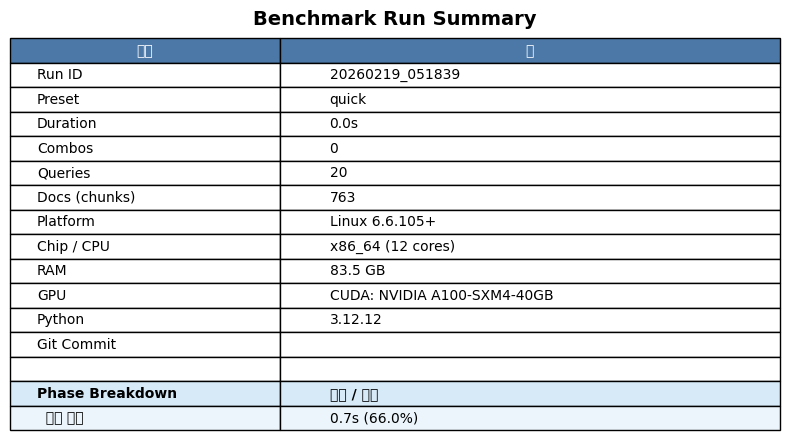


--- Phase Timeline ---


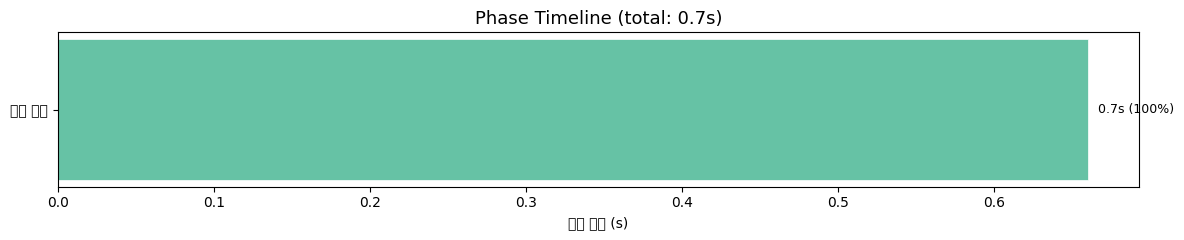

In [ ]:
# 수행 이력 요약 (RunTracker 연동)
run_record = runner.get_run_record()
if run_record:
    from colab_visualizer import plot_run_info, plot_phase_timeline
    print("--- Run Summary ---")
    plot_run_info(run_record)
    print("\n--- Phase Timeline ---")
    plot_phase_timeline(run_record)
else:
    print("RunTracker 데이터가 없습니다.")

In [ ]:
# 레이더 차트 (RAGAS 메트릭)
from colab_visualizer import plot_ragas_radar
plot_ragas_radar(ragas_df, top_n=min(5, len(ragas_df)))

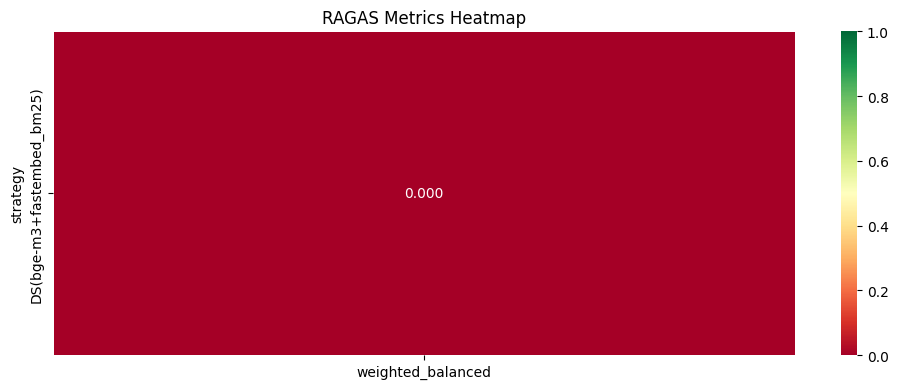

In [ ]:
# 히트맵 (전략 x 메트릭)
from colab_visualizer import plot_ragas_heatmap
plot_ragas_heatmap(ragas_df)

In [ ]:
# 파레토 프론티어 (레이턴시 vs 품질)
from colab_visualizer import plot_latency_vs_quality
plot_latency_vs_quality(latency_df, ragas_df)

KeyError: "['faithfulness'] not in index"

In [ ]:
# 레이어별 기여도 분석
from colab_visualizer import plot_layer_contribution
plot_layer_contribution(combos, latency_df, metric="avg_latency")

---
## Section 9: 비용 요약 + 결과 저장

In [ ]:
# 비용 요약 (추정)
n_ragas_strategies = len(ragas_df) if ragas_df is not None else 0
n_queries = len(queries)
est_ragas_cost = n_ragas_strategies * n_queries * 0.005  # ~$0.005/query/strategy
est_graphrag_indexing_cost = 1.0 if runner.include_graphrag else 0.0  # 지식 그래프 구축

cost_data = {
    "RAGAS 평가 (GPT-4o-mini)": est_ragas_cost,
    "Answer 생성 (GPT-3.5-turbo)": n_ragas_strategies * n_queries * 0.001,
    "GraphRAG 인덱싱 (LLM)": est_graphrag_indexing_cost,
}
total_cost = sum(cost_data.values())

print(f"예상 API 비용:")
for k, v in cost_data.items():
    print(f"  {k}: ${v:.2f}")
print(f"  총계: ${total_cost:.2f}")

from colab_visualizer import plot_cost_breakdown
if total_cost > 0:
    plot_cost_breakdown(cost_data)

In [ ]:
# 결과 Export (Google Drive)
output_dir = runner.export_results(
    latency_df=latency_df,
    ragas_df=ragas_df,
)
print(f"\n결과 저장 위치: {output_dir}")